# Company Financial Indicators

Use this notebook to inspect financial indicators for one public company.

This notebook focuses on interpretation rather than raw accounting size. It includes profitability, liquidity, leverage, and efficiency indicators.

What you can change:

- `ticker`: one Yahoo Finance symbol, for example `AAPL`, `MSFT`, or `NVDA`.
- `years`: number of recent annual fiscal periods to show.

Percent indicators are displayed as percentages. Other indicators are displayed as simple ratios such as `1.25x`.

In [1]:
from pathlib import Path
import sys
from IPython.display import display

# Find the project root whether this notebook is opened from the repo root
# or from quick_views/notebooks.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next(path for path in candidates if (path / "utils.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from quick_views.company_financial_overview import (
    build_company_financial_overview,
    format_indicator_frame,
    latest_values,
    plot_indicators,
)

print(f"Project root: {project_root}")

Project root: C:\Users\lnazareno\OneDrive - European Banking Authority\Documents\Projects\financial_analysis


## Inputs

Edit this cell and rerun the cells below.

In [2]:
ticker = "AAPL"
years = 4

## Latest Indicators

- Gross, operating, and net margins show how much profit remains from revenue.
- ROA, ROE, and ROI / ROIC Approx show returns earned on assets, equity, and invested capital.
- Current, quick, and cash ratios show short-term liquidity.
- Debt and liability ratios show leverage.
- Turnover ratios show how efficiently assets, inventory, and receivables support sales.

In [3]:
overview = build_company_financial_overview(ticker)

latest_indicator_table = format_indicator_frame(latest_values(overview.indicators)).to_frame("value")
display(latest_indicator_table)

,value
Gross Margin,46.91%
Operating Margin,31.97%
Net Margin,26.92%
ROA,31.18%
ROE,151.91%
ROI / ROIC Approx,77.18%
Current Ratio,0.89x
Quick Ratio,0.77x
Cash Ratio,0.33x
Working Capital To Revenue,-4.25%


## Recent History

Use this table to see whether the indicators are improving or deteriorating over recent fiscal years.

In [4]:
indicators_recent = overview.indicators.tail(years)
display(format_indicator_frame(indicators_recent))

,Gross Margin,Operating Margin,Net Margin,ROA,ROE,ROI / ROIC Approx,Current Ratio,Quick Ratio,Cash Ratio,Working Capital To Revenue,Debt To Equity,Debt To Assets,Liabilities To Assets,Net Debt To EBITDA,Asset Turnover,Inventory Turnover,Receivables Turnover
2022-09-30,43.31%,30.29%,25.31%,28.29%,196.96%,69.95%,0.88x,0.71x,0.31x,-4.71%,2.61x,37.56%,85.64%,0.74x,1.12x,45.20x,6.47x
2023-09-30,44.13%,29.82%,25.31%,27.51%,156.08%,65.98%,0.99x,0.84x,0.42x,-0.45%,1.79x,31.51%,82.37%,0.64x,1.09x,33.82x,6.28x
2024-09-30,46.21%,31.51%,23.97%,25.68%,164.59%,75.33%,0.87x,0.75x,0.37x,-5.99%,1.87x,29.22%,84.40%,0.57x,1.07x,28.87x,5.90x
2025-09-30,46.91%,31.97%,26.92%,31.18%,151.91%,77.18%,0.89x,0.77x,0.33x,-4.25%,1.34x,27.46%,79.48%,0.43x,1.16x,38.64x,5.70x


## Chart

The chart separates indicators into panels with clear units: margins and returns are percentages, liquidity and debt coverage are ratios, debt/liability share is a percentage, and turnover is a ratio.

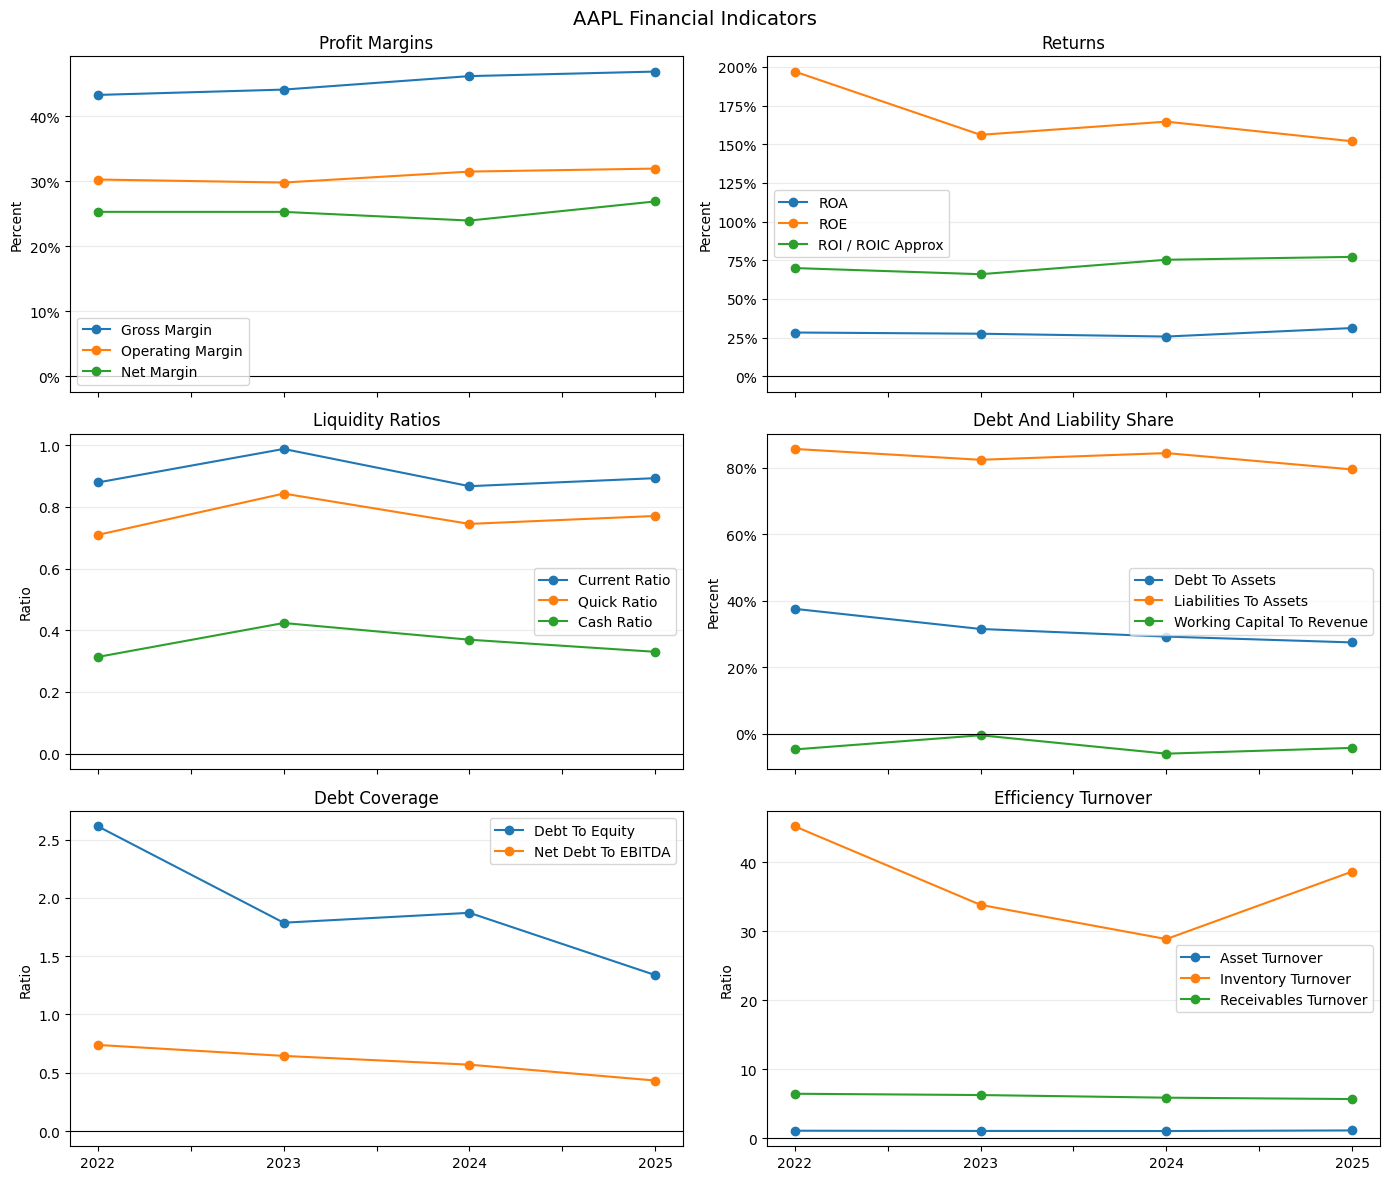

In [5]:
plot_indicators(ticker, overview.indicators, years)